*Import necessary modules*

In [1]:
from tensorflow.keras.datasets.cifar100 import load_data
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Model
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

*Display loaded data*

In [2]:
def display_img(img_set, title_set):
  n = len(title_set)
  plt.figure(figsize=(10, 6))
  for i in range(n):
    plt.subplot(3, 3, i + 1)
    plt.imshow(img_set[i], cmap = 'gray')
    plt.title(title_set[i])
  plt.tight_layout()
  plt.show()
  plt.close()

*Load CIFAR 100 Dataset*

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
trainX.shape: (50000, 32, 32, 3), trainY.shape: (50000, 1), testX.shape: (10000, 32, 32, 3), testY.shape: (10000, 1))
trainX.dtype: uint8, trainY.dtype: int64, testX.dtype: uint8, testY.dtype: int64
trainX.Range: 255 - 0, testX.Range: 255 - 0


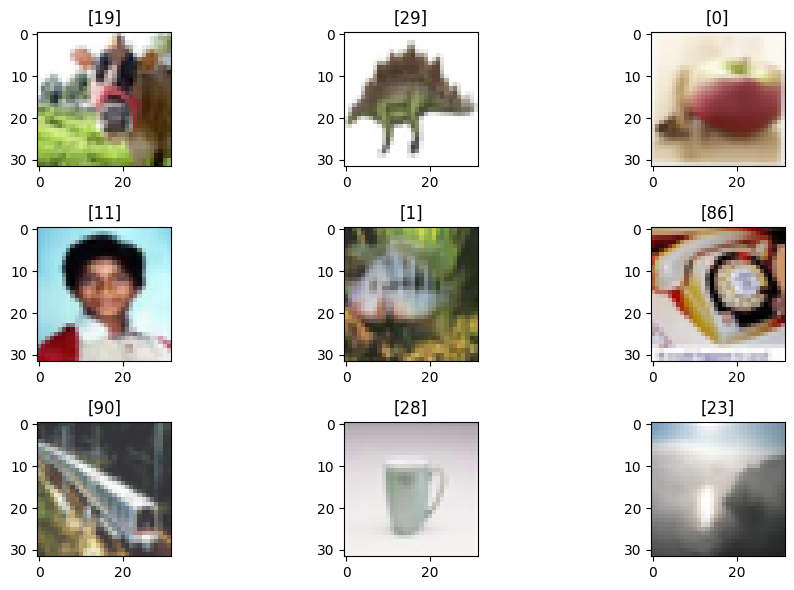

In [3]:
# Load data
(raw_trainX, raw_trainY), (raw_testX, raw_testY) = load_data(label_mode='fine')

# Investigate loaded data
print('trainX.shape: {}, trainY.shape: {}, testX.shape: {}, testY.shape: {})'.format(raw_trainX.shape, raw_trainY.shape, raw_testX.shape, raw_testY.shape))
print('trainX.dtype: {}, trainY.dtype: {}, testX.dtype: {}, testY.dtype: {}'.format(raw_trainX.dtype, raw_trainY.dtype, raw_testX.dtype, raw_testY.dtype))
print('trainX.Range: {} - {}, testX.Range: {} - {}'.format(raw_trainX.max(), raw_trainX.min(), raw_testX.max(), raw_testX.min()))

# Dispaly some loaded image data
display_img(raw_trainX[:9], raw_trainY[:9])

*Filtered the Dataset for class 20*

In [4]:
def filter_classes(X, Y, classes):
    filtered_X = []
    filtered_Y = []
    for i in range(len(Y)):
        if Y[i] in classes:
            filtered_X.append(X[i])
            filtered_Y.append(Y[i])
    return np.array(filtered_X), np.array(filtered_Y)

classes = np.arange(20)
trainX, trainY = filter_classes(raw_trainX, raw_trainY, classes)
testX, testY = filter_classes(raw_testX, raw_testY, classes)

*Display the Filtered Dataset for class 20*

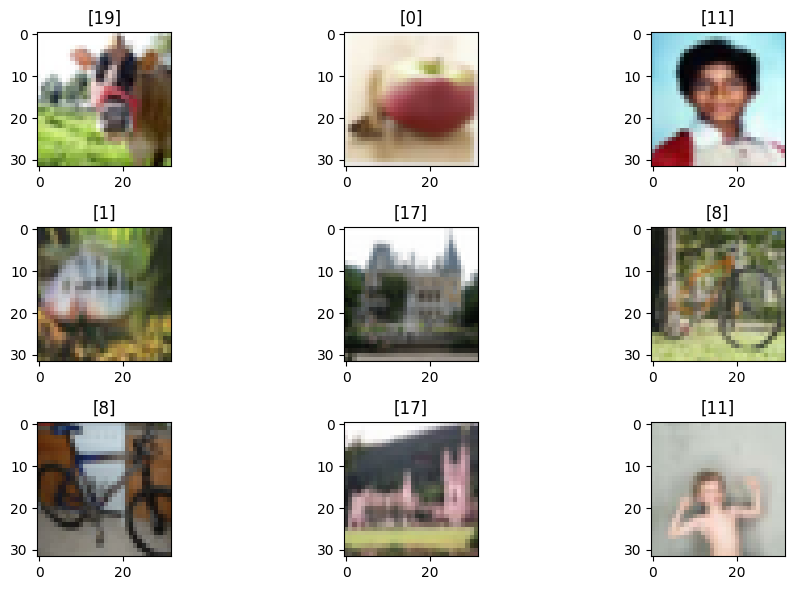

In [5]:
display_img(trainX[:9], trainY[:9])

In [6]:
# Normalize the data
trainX = trainX.astype('float32') / 255.0
testX = testX.astype('float32') / 255.0

# one-hot encode labels
trainY = to_categorical(trainY, num_classes=20)
testY = to_categorical(testY, num_classes=20)

In [7]:
results = []

# VGG16

In [8]:
from tensorflow.keras.applications import vgg16

In [9]:
vgg16_model = vgg16.VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs=vgg16_model.input
x=vgg16_model.output
x = Flatten(name='flatten')(x)
x = Dense(256, activation='relu', name='dense_1')(x)
outputs = Dense(20, activation='softmax', name='output_layer')(x)
model = Model(inputs, outputs, name='PretrainedVGG16')
model.summary(show_trainable=True)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "PretrainedVGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer (InputLayer)            │ (None, 32, 32, 3)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block1_conv1 (Conv2D)               │ (None, 32, 32, 64)           │         1,792 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block1_conv2 (Conv2D)               │ (None, 32, 32, 64)           │        36,928 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block1_pool (MaxPooling2D)          │ (None, 16, 16, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block2_conv1 (Conv2D)               │ (None, 16, 16, 128)          │        73,856 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block2_conv2 (Conv2D)               │ (None, 16, 16, 128)          │       147,584 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block2_pool (MaxPooling2D)          │ (None, 8, 8, 128)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv1 (Conv2D)               │ (None, 8, 8, 256)            │       295,168 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv2 (Conv2D)               │ (None, 8, 8, 256)            │       590,080 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv3 (Conv2D)               │ (None, 8, 8, 256)            │       590,080 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_pool (MaxPooling2D)          │ (None, 4, 4, 256)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv1 (Conv2D)               │ (None, 4, 4, 512)            │     1,180,160 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv2 (Conv2D)               │ (None, 4, 4, 512)            │     2,359,808 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv3 (Conv2D)               │ (None, 4, 4, 512)            │     2,359,808 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_pool (MaxPooling2D)          │ (None, 2, 2, 512)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_conv1 (Conv2D)               │ (None, 2, 2, 512)            │     2,359,808 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_conv2 (Conv2D)               │ (None, 2, 2, 512)            │     2,359,808 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_conv3 (Conv2D)               │ (None, 2, 2, 512)            │     2,359,808 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_pool (MaxPooling2D)          │ (None, 1, 1, 512)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ flatten (Flatten)    

 Total params: 14,851,156 (56.65 MB)

 Trainable params: 14,851,156 (56.65 MB)

 Non-trainable params: 0 (0.00 B)

*Freez the VGG16's layers and show the summary*

In [10]:
#freeze the layers of the VGG16 model
for layer in vgg16_model.layers:
    layer.trainable = False

# Unfreez the last 3 layers
for layer in vgg16_model.layers[-3:]:
    layer.trainable = True

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary(show_trainable=True)

Model: "PretrainedVGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer (InputLayer)            │ (None, 32, 32, 3)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block1_conv1 (Conv2D)               │ (None, 32, 32, 64)           │         1,792 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block1_conv2 (Conv2D)               │ (None, 32, 32, 64)           │        36,928 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block1_pool (MaxPooling2D)          │ (None, 16, 16, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block2_conv1 (Conv2D)               │ (None, 16, 16, 128)          │        73,856 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block2_conv2 (Conv2D)               │ (None, 16, 16, 128)          │       147,584 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block2_pool (MaxPooling2D)          │ (None, 8, 8, 128)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv1 (Conv2D)               │ (None, 8, 8, 256)            │       295,168 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv2 (Conv2D)               │ (None, 8, 8, 256)            │       590,080 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv3 (Conv2D)               │ (None, 8, 8, 256)            │       590,080 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_pool (MaxPooling2D)          │ (None, 4, 4, 256)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv1 (Conv2D)               │ (None, 4, 4, 512)            │     1,180,160 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv2 (Conv2D)               │ (None, 4, 4, 512)            │     2,359,808 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv3 (Conv2D)               │ (None, 4, 4, 512)            │     2,359,808 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_pool (MaxPooling2D)          │ (None, 2, 2, 512)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_conv1 (Conv2D)               │ (None, 2, 2, 512)            │     2,359,808 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_conv2 (Conv2D)               │ (None, 2, 2, 512)            │     2,359,808 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_conv3 (Conv2D)               │ (None, 2, 2, 512)            │     2,359,808 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_pool (MaxPooling2D)          │ (None, 1, 1, 512)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ flatten (Flatten)    

 Total params: 14,851,156 (56.65 MB)

 Trainable params: 4,856,084 (18.52 MB)

 Non-trainable params: 9,995,072 (38.13 MB)

*Train the head*

In [11]:
model.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.3000 - loss: 2.2519 - val_accuracy: 0.4930 - val_loss: 1.6274
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5614 - loss: 1.3925 - val_accuracy: 0.5600 - val_loss: 1.4425
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6374 - loss: 1.1508 - val_accuracy: 0.5740 - val_loss: 1.3897
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6959 - loss: 0.9491 - val_accuracy: 0.5880 - val_loss: 1.3584
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7310 - loss: 0.8284 - val_accuracy: 0.6050 - val_loss: 1.4269
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7631 - loss: 0.7268 - val_accuracy: 0.6050 - val_loss: 1.4625
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8001 - loss: 0.6199 - val_accuracy: 0.6020 - val_loss: 1.6146
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8362 - loss: 0.5026 - val_acc

*Evaluate the model's performance*

In [12]:
test_loss, test_accuracy = model.evaluate(testX, testY)
results.append(("VGG16", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6196 - loss: 1.7095


# MobileNet

In [13]:
from tensorflow.keras.applications import MobileNet

In [14]:
mobileNet_model = MobileNet(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs=mobileNet_model.input
x=mobileNet_model.output
x = Flatten(name='flatten')(x)
x = Dense(256, activation='relu', name='dense_1')(x)
outputs = Dense(20, activation='softmax', name='output_layer')(x)
model_2 = Model(inputs, outputs, name='PretrainedMobileNet')
model_2.summary(show_trainable=True)

<ipython-input-14-ff3879889493>:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobileNet_model = MobileNet(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "PretrainedMobileNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_1 (InputLayer)          │ (None, 32, 32, 3)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv1 (Conv2D)                      │ (None, 16, 16, 32)           │           864 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv1_bn (BatchNormalization)       │ (None, 16, 16, 32)           │           128 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv1_relu (ReLU)                   │ (None, 16, 16, 32)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_1 (DepthwiseConv2D)         │ (None, 16, 16, 32)           │           288 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_1_bn (BatchNormalization)   │ (None, 16, 16, 32)           │           128 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_1_relu (ReLU)               │ (None, 16, 16, 32)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_1 (Conv2D)                  │ (None, 16, 16, 64)           │         2,048 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_1_bn (BatchNormalization)   │ (None, 16, 16, 64)           │           256 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_1_relu (ReLU)               │ (None, 16, 16, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pad_2 (ZeroPadding2D)          │ (None, 17, 17, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_2 (DepthwiseConv2D)         │ (None, 8, 8, 64)             │           576 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_2_bn (BatchNormalization)   │ (None, 8, 8, 64)             │           256 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_2_relu (ReLU)               │ (None, 8, 8, 64)             │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_2 (Conv2D)                  │ (None, 8, 8, 128)            │         8,192 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_2_bn (BatchNormalization)   │ (None, 8, 8, 128)            │           512 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_2_relu (ReLU)               │ (None, 8, 8, 128)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_3 (DepthwiseConv2D)         │ (None, 8, 8, 128)            │         1,152 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_3_bn (BatchNormalization)   │ (None, 8, 8, 128)            │           512 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_3_relu (ReLU)

 Total params: 3,496,404 (13.34 MB)

 Trainable params: 3,474,516 (13.25 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [15]:
#freeze the layers of the VGG16 model
for layer in mobileNet_model.layers:
    layer.trainable = False

# Unfreez the last 3 layers
for layer in mobileNet_model.layers[-3:]:
    layer.trainable = True

# Compile the model
model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_2.summary(show_trainable=True)

Model: "PretrainedMobileNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_1 (InputLayer)          │ (None, 32, 32, 3)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv1 (Conv2D)                      │ (None, 16, 16, 32)           │           864 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv1_bn (BatchNormalization)       │ (None, 16, 16, 32)           │           128 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv1_relu (ReLU)                   │ (None, 16, 16, 32)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_1 (DepthwiseConv2D)         │ (None, 16, 16, 32)           │           288 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_1_bn (BatchNormalization)   │ (None, 16, 16, 32)           │           128 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_1_relu (ReLU)               │ (None, 16, 16, 32)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_1 (Conv2D)                  │ (None, 16, 16, 64)           │         2,048 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_1_bn (BatchNormalization)   │ (None, 16, 16, 64)           │           256 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_1_relu (ReLU)               │ (None, 16, 16, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pad_2 (ZeroPadding2D)          │ (None, 17, 17, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_2 (DepthwiseConv2D)         │ (None, 8, 8, 64)             │           576 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_2_bn (BatchNormalization)   │ (None, 8, 8, 64)             │           256 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_2_relu (ReLU)               │ (None, 8, 8, 64)             │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_2 (Conv2D)                  │ (None, 8, 8, 128)            │         8,192 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_2_bn (BatchNormalization)   │ (None, 8, 8, 128)            │           512 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_pw_2_relu (ReLU)               │ (None, 8, 8, 128)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_3 (DepthwiseConv2D)         │ (None, 8, 8, 128)            │         1,152 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_3_bn (BatchNormalization)   │ (None, 8, 8, 128)            │           512 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ conv_dw_3_relu (ReLU)

 Total params: 3,496,404 (13.34 MB)

 Trainable params: 1,318,164 (5.03 MB)

 Non-trainable params: 2,178,240 (8.31 MB)

In [16]:
# Train the mobileNet model
model_2.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.3473 - loss: 2.3686 - val_accuracy: 0.2330 - val_loss: 2.7002
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6283 - loss: 1.1691 - val_accuracy: 0.1960 - val_loss: 3.0816
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7480 - loss: 0.8009 - val_accuracy: 0.1940 - val_loss: 3.1499
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8163 - loss: 0.5839 - val_accuracy: 0.2840 - val_loss: 2.9916
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8585 - loss: 0.4375 - val_accuracy: 0.2640 - val_loss: 3.6357
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8987 - loss: 0.3187 - val_accuracy: 0.2730 - val_loss: 3.4069
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9105 - loss: 0.2761 - val_accuracy: 0.3140 - val_loss: 3.8317
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9237 - loss: 0.2292 - val_accuracy: 

In [17]:
#Evaluate MobileNetModel
test_loss, test_accuracy = model_2.evaluate(testX, testY)
results.append(("MobileNetModel", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2410 - loss: 5.4947


# DenseNet121

In [18]:
from tensorflow.keras.applications import DenseNet121

# Load DenseNet121 Model
densenet_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs = densenet_model.input
x = densenet_model.output
x = Flatten(name='flatten')(x)
x = Dense(256, activation='relu', name='dense_1')(x)
outputs = Dense(20, activation='softmax', name='output_layer')(x)
model_3 = Model(inputs, outputs, name='PretrainedDenseNet121')

# Freeze the layers of the DenseNet121 model
for layer in densenet_model.layers:
    layer.trainable = False


# UnFreeze the last two layers
for layer in densenet_model.layers[-7:]:
    layer.trainable = True

# Compile the model
model_3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_3.summary(show_trainable=True)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "PretrainedDenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape         ┃      Param # ┃ Connected to        ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_2          │ (None, 32, 32, 3)    │            0 │ -                   │    -    │
│ (InputLayer)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ zero_padding2d         │ (None, 38, 38, 3)    │            0 │ input_layer_2[0][0] │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_conv (Conv2D)    │ (None, 16, 16, 64)   │        9,408 │ zero_padding2d[0][… │    N    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_bn               │ (None, 16, 16, 64)   │          256 │ conv1_conv[0][0]    │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_relu             │ (None, 16, 16, 64)   │            0 │ conv1_bn[0][0]      │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ zero_padding2d_1       │ (None, 18, 18, 64)   │            0 │ conv1_relu[0][0]    │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ pool1 (MaxPooling2D)   │ (None, 8, 8, 64)     │            0 │ zero_padding2d_1[0… │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_0_bn      │ (None, 8, 8, 64)     │          256 │ pool1[0][0]         │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_0_relu    │ (None, 8, 8, 64)     │            0 │ conv2_block1_0_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_conv    │ (None, 8, 8, 128)    │        8,192 │ conv2_block1_0_rel… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_bn      │ (None, 8, 8, 128)    │          512 │ conv2_block1_1_con… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_relu    │ (None, 8, 8, 128)    │            0 │ conv2_block1_1_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_conv    │ (None, 8, 8, 32)     │       36,864 │ conv2_block1_1_rel… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_concat    │ (None, 8, 8, 96)     │            0 │ pool1[0][0],        │    -    │
│ (Concatenate)        

 Total params: 7,305,044 (27.87 MB)

 Trainable params: 433,684 (1.65 MB)

 Non-trainable params: 6,871,360 (26.21 MB)

In [19]:
# Train the DenseNet121 model
model_3.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 63s 138ms/step - accuracy: 0.3687 - loss: 2.1718 - val_accuracy: 0.5550 - val_loss: 1.4944
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.6107 - loss: 1.2624 - val_accuracy: 0.5840 - val_loss: 1.4570
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6744 - loss: 0.9949 - val_accuracy: 0.5590 - val_loss: 1.4591
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7183 - loss: 0.8435 - val_accuracy: 0.5760 - val_loss: 1.5048
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7804 - loss: 0.6778 - val_accuracy: 0.5880 - val_loss: 1.5394
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8265 - loss: 0.5381 - val_accuracy: 0.5810 - val_loss: 1.5832
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8538 - loss: 0.4559 - val_accuracy: 0.5900 - val_loss: 1.6978
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8861 - loss: 0.3555 - val_a

In [20]:
# Evaluate DenseNet121 Model
test_loss, test_accuracy = model_3.evaluate(testX, testY)
results.append(("DenseNet121", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.5885 - loss: 1.8064


# DenseNet169

In [21]:
from tensorflow.keras.applications import DenseNet169

# Load DenseNet169 Model
densenet169_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs = densenet169_model.input
x = densenet169_model.output
x = Flatten(name='flatten_densenet169')(x)
x = Dense(256, activation='relu', name='dense_1_densenet169')(x)
outputs = Dense(20, activation='softmax', name='output_layer_densenet169')(x)
model_4 = Model(inputs, outputs, name='PretrainedDenseNet169')

# Freeze the layers of the DenseNet169 model
for layer in densenet169_model.layers:
    layer.trainable = False

# UnFreeze the last two layers
for layer in densenet169_model.layers[-7:]:
    layer.trainable = True

# Compile the model
model_4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_4.summary(show_trainable=True)


51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "PretrainedDenseNet169"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape         ┃      Param # ┃ Connected to        ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_3          │ (None, 32, 32, 3)    │            0 │ -                   │    -    │
│ (InputLayer)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ zero_padding2d_2       │ (None, 38, 38, 3)    │            0 │ input_layer_3[0][0] │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_conv (Conv2D)    │ (None, 16, 16, 64)   │        9,408 │ zero_padding2d_2[0… │    N    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_bn               │ (None, 16, 16, 64)   │          256 │ conv1_conv[0][0]    │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_relu             │ (None, 16, 16, 64)   │            0 │ conv1_bn[0][0]      │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ zero_padding2d_3       │ (None, 18, 18, 64)   │            0 │ conv1_relu[0][0]    │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ pool1 (MaxPooling2D)   │ (None, 8, 8, 64)     │            0 │ zero_padding2d_3[0… │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_0_bn      │ (None, 8, 8, 64)     │          256 │ pool1[0][0]         │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_0_relu    │ (None, 8, 8, 64)     │            0 │ conv2_block1_0_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_conv    │ (None, 8, 8, 128)    │        8,192 │ conv2_block1_0_rel… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_bn      │ (None, 8, 8, 128)    │          512 │ conv2_block1_1_con… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_relu    │ (None, 8, 8, 128)    │            0 │ conv2_block1_1_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_conv    │ (None, 8, 8, 32)     │       36,864 │ conv2_block1_1_rel… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_concat    │ (None, 8, 8, 96)     │            0 │ pool1[0][0],        │    -    │
│ (Concatenate)        

 Total params: 13,074,260 (49.87 MB)

 Trainable params: 680,724 (2.60 MB)

 Non-trainable params: 12,393,536 (47.28 MB)

In [22]:
# Train the DenseNet169 model
model_4.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 78s 160ms/step - accuracy: 0.3996 - loss: 2.0428 - val_accuracy: 0.5590 - val_loss: 1.4101
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.6290 - loss: 1.1442 - val_accuracy: 0.5740 - val_loss: 1.3763
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7197 - loss: 0.8785 - val_accuracy: 0.5930 - val_loss: 1.4255
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7719 - loss: 0.7051 - val_accuracy: 0.5760 - val_loss: 1.5804
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8160 - loss: 0.5537 - val_accuracy: 0.5840 - val_loss: 1.5517
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8725 - loss: 0.3963 - val_accuracy: 0.6010 - val_loss: 1.6531
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8921 - loss: 0.3346 - val_accuracy: 0.6030 - val_loss: 1.6905
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9195 - loss: 0.2524 - val_

In [23]:
# Evaluate DenseNet169 Model
test_loss, test_accuracy = model_4.evaluate(testX, testY)
results.append(("DenseNet169", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.5977 - loss: 1.9260


# DenseNet201

In [24]:
from tensorflow.keras.applications import DenseNet201

# Load DenseNet201 Model
densenet201_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs = densenet201_model.input
x = densenet201_model.output
x = Flatten(name='flatten_densenet201')(x)
x = Dense(256, activation='relu', name='dense_1_densenet201')(x)
outputs = Dense(20, activation='softmax', name='output_layer_densenet201')(x)
model_5 = Model(inputs, outputs, name='PretrainedDenseNet201')

# Freeze the layers of the DenseNet201 model
for layer in densenet201_model.layers:
    layer.trainable = False

# UnFreeze the last two layers
for layer in densenet201_model.layers[-4:]:
    layer.trainable = True

# Compile the model
model_5.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_5.summary(show_trainable=True)


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "PretrainedDenseNet201"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape         ┃      Param # ┃ Connected to        ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_4          │ (None, 32, 32, 3)    │            0 │ -                   │    -    │
│ (InputLayer)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ zero_padding2d_4       │ (None, 38, 38, 3)    │            0 │ input_layer_4[0][0] │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_conv (Conv2D)    │ (None, 16, 16, 64)   │        9,408 │ zero_padding2d_4[0… │    N    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_bn               │ (None, 16, 16, 64)   │          256 │ conv1_conv[0][0]    │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_relu             │ (None, 16, 16, 64)   │            0 │ conv1_bn[0][0]      │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ zero_padding2d_5       │ (None, 18, 18, 64)   │            0 │ conv1_relu[0][0]    │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ pool1 (MaxPooling2D)   │ (None, 8, 8, 64)     │            0 │ zero_padding2d_5[0… │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_0_bn      │ (None, 8, 8, 64)     │          256 │ pool1[0][0]         │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_0_relu    │ (None, 8, 8, 64)     │            0 │ conv2_block1_0_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_conv    │ (None, 8, 8, 128)    │        8,192 │ conv2_block1_0_rel… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_bn      │ (None, 8, 8, 128)    │          512 │ conv2_block1_1_con… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_relu    │ (None, 8, 8, 128)    │            0 │ conv2_block1_1_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_conv    │ (None, 8, 8, 32)     │       36,864 │ conv2_block1_1_rel… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_concat    │ (None, 8, 8, 96)     │            0 │ pool1[0][0],        │    -    │
│ (Concatenate)        

 Total params: 18,818,900 (71.79 MB)

 Trainable params: 537,620 (2.05 MB)

 Non-trainable params: 18,281,280 (69.74 MB)

In [25]:
# Train the DenseNet201 model
model_5.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 113s 254ms/step - accuracy: 0.3851 - loss: 2.0978 - val_accuracy: 0.5130 - val_loss: 1.4777
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 57s 23ms/step - accuracy: 0.6116 - loss: 1.2249 - val_accuracy: 0.5500 - val_loss: 1.4069
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6848 - loss: 0.9903 - val_accuracy: 0.5520 - val_loss: 1.4772
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7404 - loss: 0.7990 - val_accuracy: 0.5450 - val_loss: 1.4756
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7995 - loss: 0.6236 - val_accuracy: 0.5700 - val_loss: 1.4767
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8346 - loss: 0.5201 - val_accuracy: 0.5470 - val_loss: 1.6147
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8723 - loss: 0.4086 - val_accuracy: 0.5810 - val_loss: 1.5773
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9076 - loss: 0.3035 - 

In [26]:
# Evaluate DenseNet201 Model
test_loss, test_accuracy = model_5.evaluate(testX, testY)
results.append(("DenseNet201", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 278ms/step - accuracy: 0.6049 - loss: 1.7405


# ResNet101

In [27]:
from tensorflow.keras.applications import ResNet101

# Load ResNet101 Model
resnet101_model = ResNet101(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs = resnet101_model.input
x = resnet101_model.output
x = Flatten(name='flatten_resnet101')(x)
x = Dense(256, activation='relu', name='dense_1_resnet101')(x)
outputs = Dense(20, activation='softmax', name='output_layer_resnet101')(x)
model_6 = Model(inputs, outputs, name='PretrainedResNet101')

# Freeze the layers of the ResNet101 model
for layer in resnet101_model.layers:
    layer.trainable = False

# UnFreeze the last two layers
for layer in resnet101_model.layers[-3:]:
    layer.trainable = True

# Compile the model
model_6.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_6.summary(show_trainable=True)

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "PretrainedResNet101"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape         ┃      Param # ┃ Connected to        ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_5          │ (None, 32, 32, 3)    │            0 │ -                   │    -    │
│ (InputLayer)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_pad              │ (None, 38, 38, 3)    │            0 │ input_layer_5[0][0] │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_conv (Conv2D)    │ (None, 16, 16, 64)   │        9,472 │ conv1_pad[0][0]     │    N    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_bn               │ (None, 16, 16, 64)   │          256 │ conv1_conv[0][0]    │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_relu             │ (None, 16, 16, 64)   │            0 │ conv1_bn[0][0]      │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ pool1_pad              │ (None, 18, 18, 64)   │            0 │ conv1_relu[0][0]    │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ pool1_pool             │ (None, 8, 8, 64)     │            0 │ pool1_pad[0][0]     │    -    │
│ (MaxPooling2D)         │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_conv    │ (None, 8, 8, 64)     │        4,160 │ pool1_pool[0][0]    │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_bn      │ (None, 8, 8, 64)     │          256 │ conv2_block1_1_con… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_relu    │ (None, 8, 8, 64)     │            0 │ conv2_block1_1_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_conv    │ (None, 8, 8, 64)     │       36,928 │ conv2_block1_1_rel… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_bn      │ (None, 8, 8, 64)     │          256 │ conv2_block1_2_con… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_relu    │ (None, 8, 8, 64)     │            0 │ conv2_block1_2_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_0_conv  

 Total params: 43,187,860 (164.75 MB)

 Trainable params: 533,780 (2.04 MB)

 Non-trainable params: 42,654,080 (162.71 MB)

In [28]:
# Train the ResNet101 model
model_6.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 39s 73ms/step - accuracy: 0.0851 - loss: 3.0378 - val_accuracy: 0.0740 - val_loss: 2.9584
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1508 - loss: 2.7958 - val_accuracy: 0.1440 - val_loss: 2.8313
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.1708 - loss: 2.7216 - val_accuracy: 0.1560 - val_loss: 2.7473
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1940 - loss: 2.6888 - val_accuracy: 0.1990 - val_loss: 2.7028
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2072 - loss: 2.6340 - val_accuracy: 0.1820 - val_loss: 2.6792
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2106 - loss: 2.6154 - val_accuracy: 0.1680 - val_loss: 2.7289
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2123 - loss: 2.5880 - val_accuracy: 0.1950 - val_loss: 2.6411
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2289 - loss: 2.5572 - val_acc

In [29]:
# Evaluate ResNet101 Model
test_loss, test_accuracy = model_6.evaluate(testX, testY)
results.append(("ResNet101", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.2455 - loss: 2.5360


# ResNet152

In [30]:
from tensorflow.keras.applications import ResNet152

# Load ResNet152 Model
resnet152_model = ResNet152(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs = resnet152_model.input
x = resnet152_model.output
x = Flatten(name='flatten_resnet152')(x)
x = Dense(256, activation='relu', name='dense_1_resnet152')(x)
outputs = Dense(20, activation='softmax', name='output_layer_resnet152')(x)
model_7 = Model(inputs, outputs, name='PretrainedResNet152')

# Freeze the layers of the ResNet152 model
for layer in resnet152_model.layers:
    layer.trainable = False

# UnFreeze the last two layers
for layer in resnet152_model.layers[-15:]:
    layer.trainable = True

# Compile the model
model_7.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_7.summary(show_trainable=True)

234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "PretrainedResNet152"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape         ┃      Param # ┃ Connected to        ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_6          │ (None, 32, 32, 3)    │            0 │ -                   │    -    │
│ (InputLayer)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_pad              │ (None, 38, 38, 3)    │            0 │ input_layer_6[0][0] │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_conv (Conv2D)    │ (None, 16, 16, 64)   │        9,472 │ conv1_pad[0][0]     │    N    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_bn               │ (None, 16, 16, 64)   │          256 │ conv1_conv[0][0]    │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_relu             │ (None, 16, 16, 64)   │            0 │ conv1_bn[0][0]      │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ pool1_pad              │ (None, 18, 18, 64)   │            0 │ conv1_relu[0][0]    │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ pool1_pool             │ (None, 8, 8, 64)     │            0 │ pool1_pad[0][0]     │    -    │
│ (MaxPooling2D)         │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_conv    │ (None, 8, 8, 64)     │        4,160 │ pool1_pool[0][0]    │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_bn      │ (None, 8, 8, 64)     │          256 │ conv2_block1_1_con… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_relu    │ (None, 8, 8, 64)     │            0 │ conv2_block1_1_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_conv    │ (None, 8, 8, 64)     │       36,928 │ conv2_block1_1_rel… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_bn      │ (None, 8, 8, 64)     │          256 │ conv2_block1_2_con… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_relu    │ (None, 8, 8, 64)     │            0 │ conv2_block1_2_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_0_conv  

 Total params: 58,900,628 (224.69 MB)

 Trainable params: 6,050,068 (23.08 MB)

 Non-trainable params: 52,850,560 (201.61 MB)

In [31]:
# Train the ResNet152 model
model_7.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 60s 106ms/step - accuracy: 0.1187 - loss: 3.0076 - val_accuracy: 0.0820 - val_loss: 3.1774
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.2025 - loss: 2.6328 - val_accuracy: 0.0870 - val_loss: 4.2683
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.2248 - loss: 2.5326 - val_accuracy: 0.0750 - val_loss: 6.1040
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.2460 - loss: 2.4585 - val_accuracy: 0.0530 - val_loss: 6.2720
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.2642 - loss: 2.3922 - val_accuracy: 0.0780 - val_loss: 3.8380
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.2982 - loss: 2.2778 - val_accuracy: 0.1330 - val_loss: 4.1605
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.3082 - loss: 2.2766 - val_accuracy: 0.1010 - val_loss: 5.5391
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.3139 - loss: 2.2399 - val_a

In [32]:
# Evaluate ResNet152 Model
test_loss, test_accuracy = model_7.evaluate(testX, testY)
results.append(("ResNet152", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.0963 - loss: 3.6974


# ResNet50

In [33]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50 Model
resnet50_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs = resnet50_model.input
x = resnet50_model.output
x = Flatten(name='flatten_resnet50')(x)
x = Dense(256, activation='relu', name='dense_1_resnet50')(x)
outputs = Dense(20, activation='softmax', name='output_layer_resnet50')(x)
model_8 = Model(inputs, outputs, name='PretrainedResNet50')

# Freeze the layers of the ResNet50 model
for layer in resnet50_model.layers:
    layer.trainable = False

# UnFreeze the last two layers
for layer in resnet50_model.layers[-3:]:
    layer.trainable = True

# Compile the model
model_8.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_8.summary(show_trainable=True)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "PretrainedResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape         ┃      Param # ┃ Connected to        ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_7          │ (None, 32, 32, 3)    │            0 │ -                   │    -    │
│ (InputLayer)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_pad              │ (None, 38, 38, 3)    │            0 │ input_layer_7[0][0] │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_conv (Conv2D)    │ (None, 16, 16, 64)   │        9,472 │ conv1_pad[0][0]     │    N    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_bn               │ (None, 16, 16, 64)   │          256 │ conv1_conv[0][0]    │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv1_relu             │ (None, 16, 16, 64)   │            0 │ conv1_bn[0][0]      │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ pool1_pad              │ (None, 18, 18, 64)   │            0 │ conv1_relu[0][0]    │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ pool1_pool             │ (None, 8, 8, 64)     │            0 │ pool1_pad[0][0]     │    -    │
│ (MaxPooling2D)         │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_conv    │ (None, 8, 8, 64)     │        4,160 │ pool1_pool[0][0]    │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_bn      │ (None, 8, 8, 64)     │          256 │ conv2_block1_1_con… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_1_relu    │ (None, 8, 8, 64)     │            0 │ conv2_block1_1_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_conv    │ (None, 8, 8, 64)     │       36,928 │ conv2_block1_1_rel… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_bn      │ (None, 8, 8, 64)     │          256 │ conv2_block1_2_con… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_2_relu    │ (None, 8, 8, 64)     │            0 │ conv2_block1_2_bn[… │    -    │
│ (Activation)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ conv2_block1_0_conv  

 Total params: 24,117,396 (92.00 MB)

 Trainable params: 533,780 (2.04 MB)

 Non-trainable params: 23,583,616 (89.96 MB)

In [34]:
# Train the ResNet50 model
model_8.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)


Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.1341 - loss: 2.9841 - val_accuracy: 0.0880 - val_loss: 2.9539
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2476 - loss: 2.4978 - val_accuracy: 0.2050 - val_loss: 2.6191
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2842 - loss: 2.3481 - val_accuracy: 0.2660 - val_loss: 2.4344
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3260 - loss: 2.2255 - val_accuracy: 0.2700 - val_loss: 2.4741
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3442 - loss: 2.1593 - val_accuracy: 0.2760 - val_loss: 2.4815
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3594 - loss: 2.0825 - val_accuracy: 0.3070 - val_loss: 2.3351
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3994 - loss: 1.9902 - val_accuracy: 0.2940 - val_loss: 2.4219
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4155 - loss: 1.9184 - val_accuracy

In [35]:
# Evaluate ResNet50 Model
test_loss, test_accuracy = model_8.evaluate(testX, testY)
results.append(("ResNet50", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3216 - loss: 2.3796


# VGG19

In [36]:
from tensorflow.keras.applications import VGG19

# Load VGG19 Model
vgg19_model = VGG19(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs = vgg19_model.input
x = vgg19_model.output
x = Flatten(name='flatten_vgg19')(x)
x = Dense(256, activation='relu', name='dense_1_vgg19')(x)
outputs = Dense(20, activation='softmax', name='output_layer_vgg19')(x)
model_9 = Model(inputs, outputs, name='PretrainedVGG19')

# Freeze the layers of the VGG19 model
for layer in vgg19_model.layers:
    layer.trainable = False

# UnFreeze the last two layers
for layer in vgg19_model.layers[-3:]:
    layer.trainable = True

# Compile the model
model_9.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_9.summary(show_trainable=True)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "PretrainedVGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_8 (InputLayer)          │ (None, 32, 32, 3)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block1_conv1 (Conv2D)               │ (None, 32, 32, 64)           │         1,792 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block1_conv2 (Conv2D)               │ (None, 32, 32, 64)           │        36,928 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block1_pool (MaxPooling2D)          │ (None, 16, 16, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block2_conv1 (Conv2D)               │ (None, 16, 16, 128)          │        73,856 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block2_conv2 (Conv2D)               │ (None, 16, 16, 128)          │       147,584 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block2_pool (MaxPooling2D)          │ (None, 8, 8, 128)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv1 (Conv2D)               │ (None, 8, 8, 256)            │       295,168 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv2 (Conv2D)               │ (None, 8, 8, 256)            │       590,080 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv3 (Conv2D)               │ (None, 8, 8, 256)            │       590,080 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_conv4 (Conv2D)               │ (None, 8, 8, 256)            │       590,080 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block3_pool (MaxPooling2D)          │ (None, 4, 4, 256)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv1 (Conv2D)               │ (None, 4, 4, 512)            │     1,180,160 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv2 (Conv2D)               │ (None, 4, 4, 512)            │     2,359,808 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv3 (Conv2D)               │ (None, 4, 4, 512)            │     2,359,808 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_conv4 (Conv2D)               │ (None, 4, 4, 512)            │     2,359,808 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block4_pool (MaxPooling2D)          │ (None, 2, 2, 512)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_conv1 (Conv2D)               │ (None, 2, 2, 512)            │     2,359,808 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_conv2 (Conv2D)               │ (None, 2, 2, 512)            │     2,359,808 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ block5_conv3 (Conv2D)

 Total params: 20,160,852 (76.91 MB)

 Trainable params: 4,856,084 (18.52 MB)

 Non-trainable params: 15,304,768 (58.38 MB)

In [37]:
# Train the VGG19 model
model_9.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3072 - loss: 2.2612 - val_accuracy: 0.4870 - val_loss: 1.6850
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5260 - loss: 1.5019 - val_accuracy: 0.5250 - val_loss: 1.5367
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5866 - loss: 1.2917 - val_accuracy: 0.5300 - val_loss: 1.5043
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6510 - loss: 1.1134 - val_accuracy: 0.5390 - val_loss: 1.4912
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6717 - loss: 0.9901 - val_accuracy: 0.5580 - val_loss: 1.5025
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7095 - loss: 0.8926 - val_accuracy: 0.5510 - val_loss: 1.6025
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7402 - loss: 0.7952 - val_accuracy: 0.5550 - val_loss: 1.7050
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7792 - loss: 0.6652 - val_accu

In [38]:
# Evaluate VGG19 Model
test_loss, test_accuracy = model_9.evaluate(testX, testY)
results.append(("VGG19", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5890 - loss: 1.7744


# MobileNetV2

In [39]:
from tensorflow.keras.applications import MobileNetV2
# Load MobileNetV2 Model
mobilenetv2_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
inputs = mobilenetv2_model.input
x = mobilenetv2_model.output
x = Flatten(name='flatten_mobilenetv2')(x)
x = Dense(256, activation='relu', name='dense_1_mobilenetv2')(x)
outputs = Dense(20, activation='softmax', name='output_layer_mobilenetv2')(x)
model_10 = Model(inputs, outputs, name='PretrainedMobileNetV2')

# Freeze the layers of the MobileNetV2 model
for layer in mobilenetv2_model.layers:
    layer.trainable = False

# UnFreeze the last two layers
for layer in mobilenetv2_model.layers[-3:]:
    layer.trainable = True

# Compile the model
model_10.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_10.summary(show_trainable=True)

<ipython-input-39-0aafd1e3d482>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenetv2_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "PretrainedMobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape         ┃      Param # ┃ Connected to        ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_9          │ (None, 32, 32, 3)    │            0 │ -                   │    -    │
│ (InputLayer)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Conv1 (Conv2D)         │ (None, 16, 16, 32)   │          864 │ input_layer_9[0][0] │    N    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ bn_Conv1               │ (None, 16, 16, 32)   │          128 │ Conv1[0][0]         │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Conv1_relu (ReLU)      │ (None, 16, 16, 32)   │            0 │ bn_Conv1[0][0]      │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ expanded_conv_depthwi… │ (None, 16, 16, 32)   │          288 │ Conv1_relu[0][0]    │    N    │
│ (DepthwiseConv2D)      │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ expanded_conv_depthwi… │ (None, 16, 16, 32)   │          128 │ expanded_conv_dept… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ expanded_conv_depthwi… │ (None, 16, 16, 32)   │            0 │ expanded_conv_dept… │    -    │
│ (ReLU)                 │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ expanded_conv_project  │ (None, 16, 16, 16)   │          512 │ expanded_conv_dept… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ expanded_conv_project… │ (None, 16, 16, 16)   │           64 │ expanded_conv_proj… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ block_1_expand         │ (None, 16, 16, 96)   │        1,536 │ expanded_conv_proj… │    N    │
│ (Conv2D)               │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ block_1_expand_BN      │ (None, 16, 16, 96)   │          384 │ block_1_expand[0][… │    N    │
│ (BatchNormalization)   │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ block_1_expand_relu    │ (None, 16, 16, 96)   │            0 │ block_1_expand_BN[… │    -    │
│ (ReLU)                 │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ block_1_pad            │ (None, 17, 17, 96)   │            0 │ block_1_expand_rel… │    -    │
│ (ZeroPadding2D)        │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ block_1_depthwise      │ (None, 8, 8, 96)     │          864 │ block_1_pad[0][0]   │    N    │
│ (DepthwiseConv2D)    

 Total params: 2,591,060 (9.88 MB)

 Trainable params: 745,236 (2.84 MB)

 Non-trainable params: 1,845,824 (7.04 MB)

In [40]:
# Train the MobileNetV2 model
model_10.fit(trainX, trainY, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.3217 - loss: 2.4587 - val_accuracy: 0.2770 - val_loss: 2.3604
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5115 - loss: 1.5722 - val_accuracy: 0.3070 - val_loss: 2.3061
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5800 - loss: 1.3282 - val_accuracy: 0.3380 - val_loss: 2.4868
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6411 - loss: 1.1127 - val_accuracy: 0.3270 - val_loss: 2.5292
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6895 - loss: 0.9822 - val_accuracy: 0.3610 - val_loss: 2.4915
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7161 - loss: 0.8600 - val_accuracy: 0.3710 - val_loss: 2.4782
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7718 - loss: 0.7149 - val_accuracy: 0.3380 - val_loss: 2.5729
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7925 - loss: 0.6330 - val_accuracy: 

In [41]:
# Evaluate MobileNetV2 Model
test_loss, test_accuracy = model_10.evaluate(testX, testY)
results.append(("MobileNetV2", test_accuracy, test_loss))

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.4286 - loss: 2.5132


Comparision

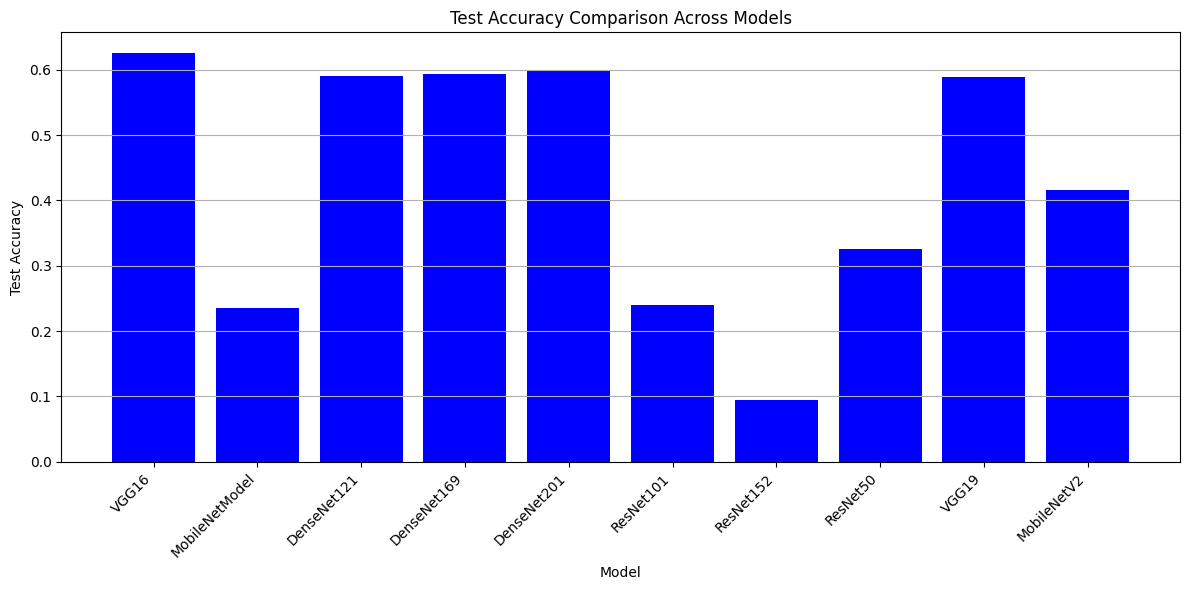

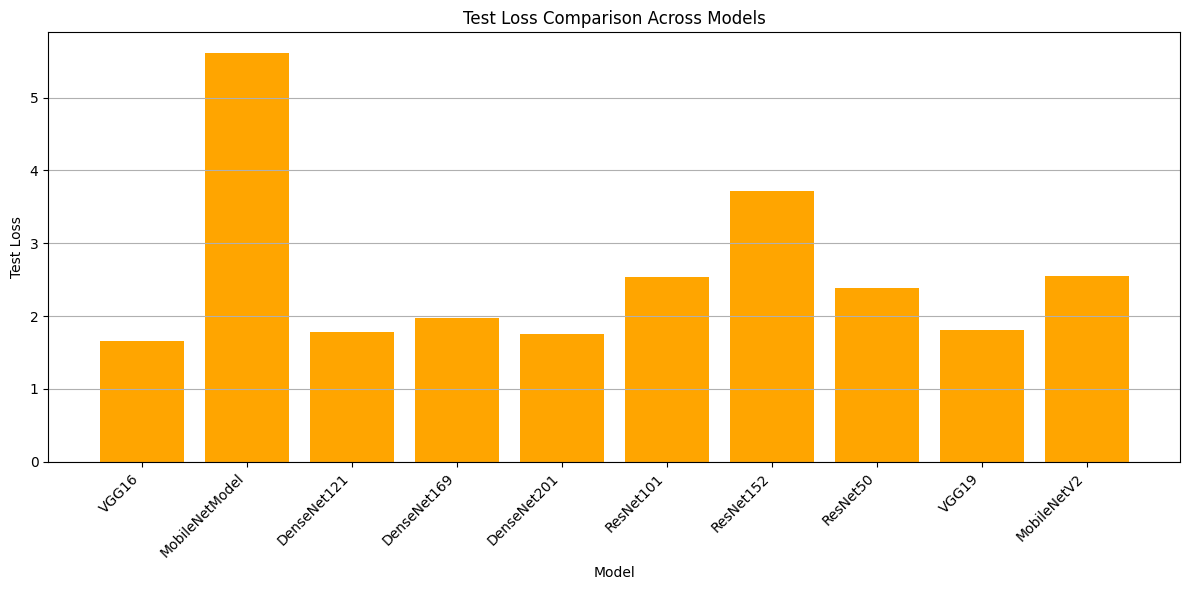

In [42]:
model_names = [m[0] for m in results]
accuracies = [m[1] for m in results]
losses = [m[2] for m in results]

plt.figure(figsize=(12, 6))
plt.bar(model_names, accuracies, color='blue')
plt.title('Test Accuracy Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
plt.close()

plt.figure(figsize=(12, 6))
plt.bar(model_names, losses, color='orange')
plt.title('Test Loss Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('Test Loss')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
plt.close()